# M2 Deep Learning Coursework: Normalizing Flows

This notebook is a scaffold for the final coursework implementation.
All major required sections are present as TODO placeholders.


## 0) Setup and Reproducibility


In [1]:
import json
import math
import random
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import Image, Markdown, display
from torch.optim.lr_scheduler import CosineAnnealingLR


In [2]:
# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

# CPU-only coursework assumption
DEVICE = torch.device('cpu')

# Ensure output directories exist before any save calls.
figs_dir = Path('figs')
figs_dir.mkdir(parents=True, exist_ok=True)
Path('checkpoints').mkdir(parents=True, exist_ok=True)
Path('logs').mkdir(parents=True, exist_ok=True)

# Keep figure outputs deterministic across runs: remove prior generated figures.
for p in figs_dir.iterdir():
    if p.name == '.gitkeep':
        continue
    if p.is_file() and p.suffix.lower() in {'.pdf', '.png'}:
        p.unlink()

def _to_jsonable(value):
    if isinstance(value, dict):
        return {str(k): _to_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_to_jsonable(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return value.item() if value.numel() == 1 else value.tolist()
    return value

def _recursive_merge_dicts(existing, updates):
    merged = dict(existing)
    for key, value in updates.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _recursive_merge_dicts(merged[key], value)
        else:
            merged[key] = value
    return merged

def update_results_json(path, updates):
    path = Path(path)
    existing = {}
    if path.exists():
        with path.open('r', encoding='utf-8') as f:
            existing = json.load(f)

    merged = _recursive_merge_dicts(existing, _to_jsonable(updates))
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile('w', encoding='utf-8', dir=path.parent, delete=False) as tmp:
        json.dump(merged, tmp, indent=2, sort_keys=True)
        tmp.write('\n')
        tmp_path = Path(tmp.name)
    tmp_path.replace(path)
    return merged


## 1) Data Loading


In [3]:
# Load CSV files; class labels are retained only for diagnostics (not training).
def load_moons_csv(path: Path):
    arr = np.genfromtxt(path, delimiter=',', names=True, dtype=np.float64)
    x = np.stack([arr['x1'], arr['x2']], axis=1).astype(np.float64)
    cls = arr['class'].astype(np.int64)
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(cls)
train_x, train_class = load_moons_csv(Path('data/moons_train.csv'))
val_x, val_class = load_moons_csv(Path('data/moons_val.csv'))
test_x, test_class = load_moons_csv(Path('data/moons_test.csv'))
for name, split_x in [('train', train_x), ('val', val_x), ('test', test_x)]:
    if split_x.ndim != 2 or split_x.shape[1] != 2:
        raise ValueError(f'{name} split must have shape [N, 2], got {tuple(split_x.shape)}')
print(f'train/val/test sizes: {len(train_x)}/{len(val_x)}/{len(test_x)}')


train/val/test sizes: 800/100/100


## 1b) Data Exploration

Here I perform a basic exploratory data analysis of the dataset across the `train`, `val`, and `test` splits.

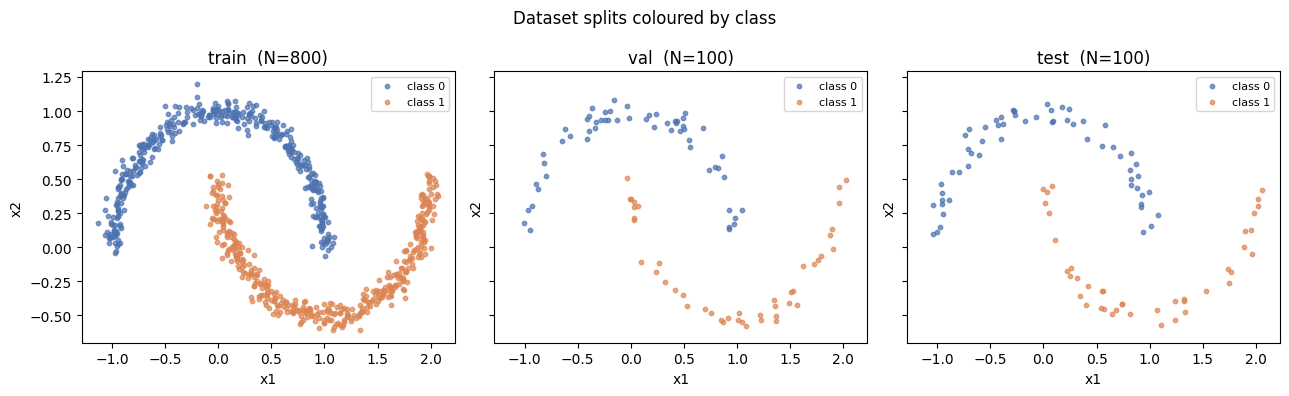

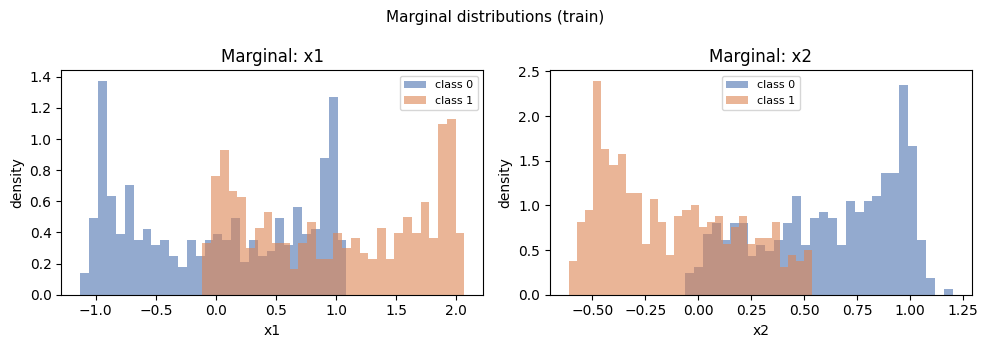

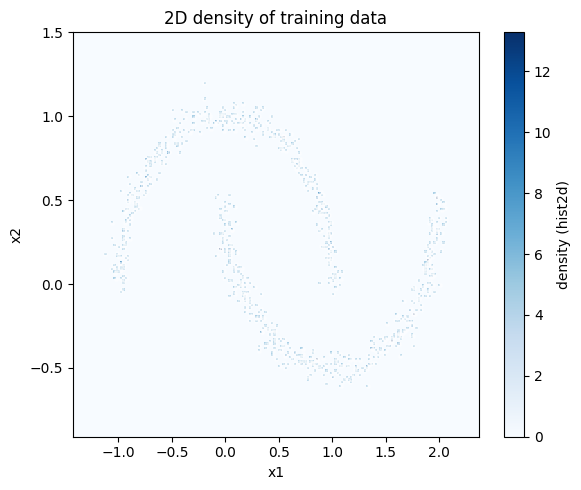

Split        N    x1 mean   x1 std   x2 mean   x2 std
-------------------------------------------------------
train      800     0.5210   0.8748    0.2313   0.4910
val        100     0.4606   0.7998    0.3343   0.5437
test       100     0.3662   0.8638    0.3227   0.5010

Train class balance: class0=385, class1=415


In [4]:
# ── Scatter plots coloured by class ──────────────────────────────────────────
splits = {'train': (train_x, train_class), 'val': (val_x, val_class), 'test': (test_x, test_class)}
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (name, (X, Y)) in zip(axes, splits.items()):
    Xn = X.numpy()
    for c, col in zip([0, 1], colors):
        m = (Y == c).numpy()
        ax.scatter(Xn[m, 0], Xn[m, 1], c=col, s=10, alpha=0.7, label=f'class {c}')
    ax.set_title(f'{name}  (N={len(X)})'); ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=8)
fig.suptitle('Dataset splits coloured by class', fontsize=12)
fig.tight_layout()
plt.show()

# ── Marginal histograms (train only) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
Xn = train_x.numpy()
for i, (ax, lbl) in enumerate(zip(axes, ['x1', 'x2'])):
    for c, col in zip([0, 1], colors):
        m = (train_class == c).numpy()
        ax.hist(Xn[m, i], bins=30, color=col, alpha=0.6, label=f'class {c}', density=True)
    ax.set_xlabel(lbl); ax.set_ylabel('density'); ax.set_title(f'Marginal: {lbl}'); ax.legend(fontsize=8)
fig.suptitle('Marginal distributions (train)', fontsize=11)
fig.tight_layout()
plt.show()

# ── 2D density heatmap (SciPy-free) ──────────────────────────────────────────
pad = 0.3
x1_min, x1_max = Xn[:, 0].min() - pad, Xn[:, 0].max() + pad
x2_min, x2_max = Xn[:, 1].min() - pad, Xn[:, 1].max() + pad
hist2d, xedges, yedges = np.histogram2d(
    Xn[:, 0],
    Xn[:, 1],
    bins=180,
    range=[[x1_min, x1_max], [x2_min, x2_max]],
    density=True,
)

fig, ax = plt.subplots(figsize=(6, 5))
pcm = ax.pcolormesh(xedges, yedges, hist2d.T, cmap='Blues', shading='auto')
ax.scatter(Xn[:, 0], Xn[:, 1], c='white', s=6, alpha=0.4)
fig.colorbar(pcm, ax=ax, label='density (hist2d)')
ax.set_title('2D density of training data'); ax.set_xlabel('x1'); ax.set_ylabel('x2')
fig.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print(f"{'Split':<8} {'N':>5}  {'x1 mean':>9} {'x1 std':>8} {'x2 mean':>9} {'x2 std':>8}")
print('-' * 55)
for name, (X, _) in splits.items():
    print(f"{name:<8} {len(X):>5}  {X[:,0].mean():>9.4f} {X[:,0].std():>8.4f} {X[:,1].mean():>9.4f} {X[:,1].std():>8.4f}")
print(f"\nTrain class balance: class0={int((train_class==0).sum())}, class1={int((train_class==1).sum())}")


I can see that the splits are broadly consistent with one another. Scatter plots reveal two curved clusters, for each of classes - which is a nonlinearly separable dataset. 


Marginal distribution allowed to look at x1 and x2 distribution on its own - I can see that x2 shows somewhat clearer separation

## 2) a. Affine Coupling Flow

In this section I have implemented a binary mask to keep one coordinate fixed and transform the other, computes s and t using a single MLP with architecture Linear(D→H) → ReLU → Linear(H→2D), bounds the scale with tanh, and implements both forward and inverse, each returning the transformed vector and the corresponding log-determinant.


In [ ]:
import math
import torch.nn as nn


class AffineCoupling2D(nn.Module):
    """Single 2D affine coupling layer with configurable binary mask."""
####validation checks 
    def __init__(self, *, dim: int, hidden: int, mask: torch.Tensor):
        super().__init__()
        if dim != 2:
            raise ValueError('This coursework implementation expects dim=2.')
        if hidden < 1 or hidden > 128:
            raise ValueError('Coursework constraint violated: hidden must be in [1, 128].')
        if mask.shape != (dim,):
            raise ValueError(f'mask must have shape ({dim},), got {tuple(mask.shape)}')
        if not torch.all((mask == 0) | (mask == 1)):
            raise ValueError('mask entries must be binary 0/1 values.')
        if int(mask.sum().item()) != (dim - 1):
            raise ValueError('mask must keep exactly dim-1 components unchanged.')

        self.dim = dim
        self.hidden = hidden
        self.register_buffer('mask', mask.to(dtype=torch.float64))

        # Required MLP: Linear(D->H) -> ReLU -> Linear(H->2D), then split into s/t.
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * dim),
        )

    def _st(self, x: torch.Tensor):
        x_masked = x * self.mask
        st = self.net(x_masked)
        s, t = torch.chunk(st, 2, dim=-1)
        s = torch.tanh(s)
        transform_mask = 1.0 - self.mask
        s = s * transform_mask
        t = t * transform_mask
        return s, t

    def forward(self, z: torch.Tensor):
        """Forward map f: base -> data. Returns transformed output and log|det J_f|."""
        s, t = self._st(z)
        transform_mask = 1.0 - self.mask
        x = z * self.mask + transform_mask * (z * torch.exp(s) + t)
        logdet = s.sum(dim=-1)
        return x, logdet

    def inverse(self, x: torch.Tensor):
        """Inverse map f^{-1}: data -> base. Returns output and log|det J_{f^{-1}}|."""
        s, t = self._st(x)
        transform_mask = 1.0 - self.mask
        z = x * self.mask + transform_mask * ((x - t) * torch.exp(-s))
        logdet = -s.sum(dim=-1)
        return z, logdet


CouplingFlow2D(
  (layers): ModuleList(
    (0-5): 6 x AffineCoupling2D(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=4, bias=True)
      )
    )
  )
)

## b. Stacking coubling layers 

- here I implement a class that takes a single-layer building block from part a and turns it into a full normalizing flow


In [ ]:

class CouplingFlow2D(nn.Module):
    """Stack of affine coupling layers with alternating masks for D=2."""

    def __init__(self, *, n_layers: int, hidden: int, dim: int = 2):
        super().__init__()
        if n_layers < 2 or n_layers > 8:
            raise ValueError('n_layers must be in [2, 8].')
        if hidden < 1 or hidden > 128:
            raise ValueError('hidden must be in [1, 128].')
        self.dim = dim
        self.n_layers = n_layers
        self.hidden = hidden

        layers = [] 
        for i in range(n_layers):
            mask = torch.tensor([1.0, 0.0]) if i % 2 == 0 else torch.tensor([0.0, 1.0])
            layers.append(AffineCoupling2D(dim=dim, hidden=hidden, mask=mask))
        self.layers = nn.ModuleList(layers) ###here I create multiple coupling layers and store them in a stack 

    def forward(self, z: torch.Tensor):   ###applying all coupling layers in order and accumulating log determinants
        x = z
        total_logdet = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)
        for layer in self.layers:
            x, logdet = layer.forward(x)
            total_logdet = total_logdet + logdet
        return x, total_logdet

    def inverse(self, x: torch.Tensor): ##applies layers in reverse order and also accumulates the log determinants
        z = x
        total_logdet = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
        for layer in reversed(self.layers):
            z, logdet = layer.inverse(z)
            total_logdet = total_logdet + logdet
        return z, total_logdet

    @staticmethod #Standar log density  
    def base_log_prob(z: torch.Tensor):
        log_2pi = math.log(2.0 * math.pi)
        return -0.5 * (z.pow(2) + log_2pi).sum(dim=-1)

    def log_prob(self, x: torch.Tensor):
        z, inv_logdet = self.inverse(x)
        return self.base_log_prob(z) + inv_logdet


# Compliant model size: hidden <= 128, n_layers <= 8.
FLOW_CONFIG = {'dim': 2, 'hidden': 64, 'n_layers': 6}
flow = CouplingFlow2D(
    dim=FLOW_CONFIG['dim'],
    hidden=FLOW_CONFIG['hidden'],
    n_layers=FLOW_CONFIG['n_layers'],
).to(DEVICE).double()
flow.eval()


I created the CouplingFlow2D class. It stacks multiple AffineCoupling2D layers with alternating masks, defines a standard normal base density through base_log_prob, and implements log_prob(x) for a batch using the inverse map and the change-of-variables formula.

## Untrained Model Diagnostics

Untrained flow NLL: train=2.8504, val=2.9160


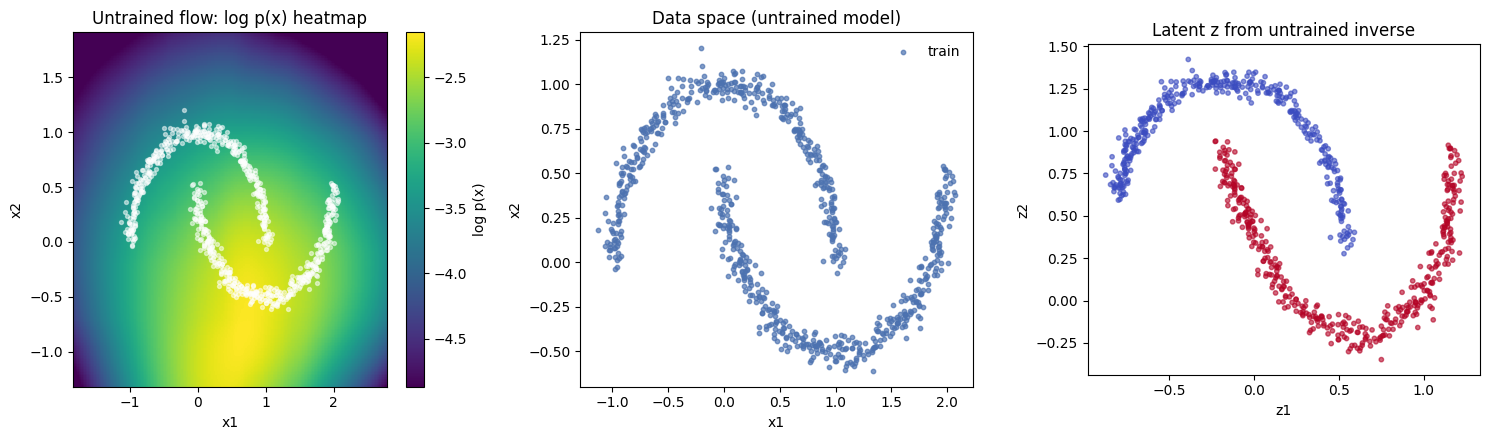

In [ ]:
GRID_N = 220
x1_r = np.linspace(train_x[:, 0].min().item() - 0.7, train_x[:, 0].max().item() + 0.7, GRID_N)
x2_r = np.linspace(train_x[:, 1].min().item() - 0.7, train_x[:, 1].max().item() + 0.7, GRID_N)
xx_g, yy_g = np.meshgrid(x1_r, x2_r)
grid_pts = torch.tensor(np.stack([xx_g.ravel(), yy_g.ravel()], axis=1), dtype=torch.float64)

with torch.no_grad():
    train_nll_untrained = -flow.log_prob(train_x).mean().item()
    val_nll_untrained = -flow.log_prob(val_x).mean().item()
    log_p_grid = flow.log_prob(grid_pts).numpy().reshape(GRID_N, GRID_N)
    z_untrained, _ = flow.inverse(train_x)

print(f'Untrained flow NLL: train={train_nll_untrained:.4f}, val={val_nll_untrained:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
im = ax.pcolormesh(xx_g, yy_g, log_p_grid, cmap='viridis', shading='auto',
                   vmin=np.percentile(log_p_grid, 5))
fig.colorbar(im, ax=ax, label='log p(x)')
ax.scatter(train_x.numpy()[:, 0], train_x.numpy()[:, 1], c='white', s=8, alpha=0.5)
ax.set_title('Untrained flow: log p(x) heatmap')
ax.set_xlabel('x1'); ax.set_ylabel('x2')

ax = axes[1]
ax.scatter(train_x.numpy()[:, 0], train_x.numpy()[:, 1], c='#4C72B0', s=10, alpha=0.7, label='train')
ax.set_title('Data space (untrained model)')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(frameon=False)

ax = axes[2]
z_np = z_untrained.numpy()
ax.scatter(z_np[:, 0], z_np[:, 1], c=train_class.numpy(), cmap='coolwarm', s=10, alpha=0.6)
ax.set_title('Latent z from untrained inverse')
ax.set_xlabel('z1'); ax.set_ylabel('z2'); ax.set_aspect('equal')

fig.tight_layout()
plt.show()


## c. correctness checks + saving the outputs 
- the correctness has been checkes of
    - invertability - sending training data into latet space, mapping it back and comparing reconstruction - took the max abs err 
    - finite-difference log-det check 
        - using the first training example, estimating Jacobian of f^{-1}, using central differences, comparing log Idet JI to analytic log-det, computing abs error 

In [1]:
# Correctness check 1: invertibility over all training points.
with torch.no_grad():
    z_train, inv_logdet_train = flow.inverse(train_x)
    x_hat, fwd_logdet_train = flow.forward(z_train)
reconstruction_abs = (x_hat - train_x).abs()
invertibility_max_abs_error = float(reconstruction_abs.max().item())

# Correctness check 2: analytic vs finite-difference inverse log-det on first training example.
epsilon = 1e-4
x0 = train_x[:1].clone()
with torch.no_grad():
    _, analytic_inv_logdet = flow.inverse(x0)
analytic_inv_logdet_value = float(analytic_inv_logdet.item())

jacobian_cols = []
for d in range(x0.shape[1]):
    delta = torch.zeros_like(x0)
    delta[0, d] = epsilon
    with torch.no_grad():
        z_plus, _ = flow.inverse(x0 + delta)
        z_minus, _ = flow.inverse(x0 - delta)
    col = ((z_plus - z_minus) / (2.0 * epsilon)).squeeze(0)
    jacobian_cols.append(col)

jacobian = torch.stack(jacobian_cols, dim=1)
sign, logabsdet = torch.linalg.slogdet(jacobian)
if float(sign.item()) <= 0.0:
    raise RuntimeError('Finite-difference Jacobian has non-positive determinant.')
finite_diff_logabsdet = float(logabsdet.item())
logdet_finite_diff_abs_error = float(abs(finite_diff_logabsdet - analytic_inv_logdet_value))

# Diagnostic figure (two panels) required by coursework.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left panel: invertibility error distribution.
pointwise_recon_err = reconstruction_abs.max(dim=1).values.cpu().numpy()
axes[0].hist(pointwise_recon_err, bins=40, color='tab:blue', alpha=0.82, edgecolor='white')
axes[0].axvline(
    invertibility_max_abs_error,
    color='tab:red',
    linestyle='--',
    linewidth=2,
    label=f'max error = {invertibility_max_abs_error:.2e}',
)
axes[0].set_title('Invertibility Check')
axes[0].set_xlabel('Per-point max |x_hat - x|')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, fontsize=9)

# Right panel: zoomed comparison of analytic vs finite-difference log-det values.
labels = ['analytic', 'finite diff']
values = np.array([analytic_inv_logdet_value, finite_diff_logabsdet], dtype=np.float64)
x = np.arange(len(labels), dtype=np.float64)

axes[1].plot(x, values, color='tab:purple', marker='o', linewidth=2, markersize=7)
for xi, yi in zip(x, values):
    axes[1].annotate(f'{yi:.8f}', (xi, yi), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

spread = float(values.max() - values.min())
if spread < 1e-10:
    pad = max(abs(values.mean()) * 1e-6, 1e-8)
else:
    pad = max(3.0 * spread, 1e-8)

axes[1].set_ylim(float(values.min() - pad), float(values.max() + pad))
axes[1].set_xticks(x, labels)
axes[1].set_ylabel('log |det J_{f^{-1}}|')
axes[1].set_title('Inverse Log-Det Check (zoomed)')
axes[1].set_xlabel(f'Absolute error: {logdet_finite_diff_abs_error:.2e}')
axes[1].grid(axis='y', alpha=0.25)
axes[1].margins(x=0.25)

fig.tight_layout()
fig.savefig('figs/Figure1c.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

# Saving required correctness outputs for this step without overwriting other sections.
results = update_results_json(
    'results.json',
    {
        'correctness': {
            'invertibility_max_abs_error': invertibility_max_abs_error,
            'logdet_finite_diff_abs_error': logdet_finite_diff_abs_error,
        }
    },
)
print(json.dumps(results, indent=2, sort_keys=True))
print('Saved figs/Figure1c.pdf')


NameError: name 'torch' is not defined

## 4) Training on Tiny Subset (First 128 Rows)

  step  500/2000  NLL=0.3692
  step 1000/2000  NLL=0.2218
  step 1000/2000  NLL=0.2218
  step 1500/2000  NLL=0.1448
  step 1500/2000  NLL=0.1448
  step 2000/2000  NLL=0.0715

Tiny-set final NLL: 0.0715
  step 2000/2000  NLL=0.0715

Tiny-set final NLL: 0.0715


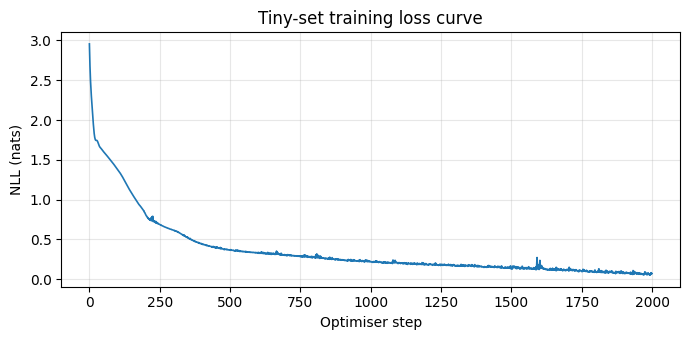

Saved figs/Figure2a.pdf


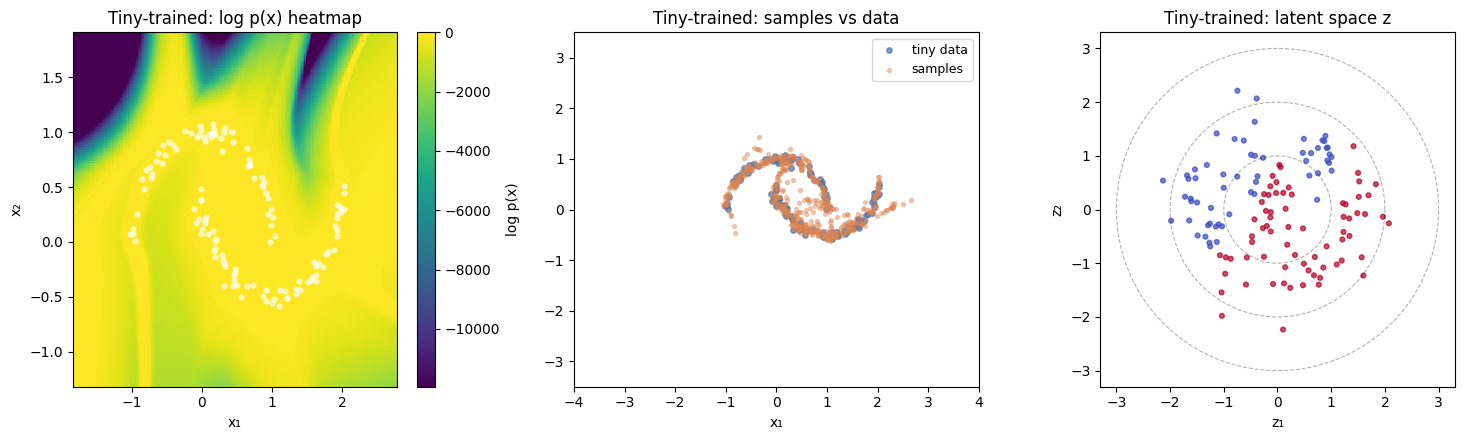

In [8]:
import torch.optim as optim

# Ensure output directory exists regardless of cell execution order.
Path('figs').mkdir(parents=True, exist_ok=True)

# ── Tiny-set Training (first 128 rows) ────────────────────────────────────────
TINY_N = 128
tiny_x = train_x[:TINY_N]

TINY_CONFIG = {'hidden': 64, 'n_layers': 6}
flow_tiny = CouplingFlow2D(dim=2, **TINY_CONFIG).to(DEVICE).double()

LR_TINY = 1e-3
N_STEPS_TINY = 2000

optimizer_tiny = optim.Adam(flow_tiny.parameters(), lr=LR_TINY)
tiny_loss_curve = []

flow_tiny.train()
for step in range(N_STEPS_TINY):
    optimizer_tiny.zero_grad()
    nll = -flow_tiny.log_prob(tiny_x).mean()
    nll.backward()
    torch.nn.utils.clip_grad_norm_(flow_tiny.parameters(), 5.0)
    optimizer_tiny.step()
    tiny_loss_curve.append(float(nll.item()))
    if (step + 1) % 500 == 0:
        print(f'  step {step+1:4d}/{N_STEPS_TINY}  NLL={nll.item():.4f}')

flow_tiny.eval()
with torch.no_grad():
    tinyset_final_nll = -flow_tiny.log_prob(tiny_x).mean().item()
print(f'\nTiny-set final NLL: {tinyset_final_nll:.4f}')

# ── Figure 2a: loss curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tiny_loss_curve, color='tab:blue', linewidth=1.2)
ax.set_xlabel('Optimiser step')
ax.set_ylabel('NLL (nats)')
ax.set_title('Tiny-set training loss curve')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('figs/Figure2a.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved figs/Figure2a.pdf')

# ── Post-training diagnostics: heatmap, samples, latent space ────────────────
with torch.no_grad():
    log_p_tiny = flow_tiny.log_prob(grid_pts).numpy().reshape(GRID_N, GRID_N)
    x_samp_tiny, _ = flow_tiny.forward(torch.randn(500, 2, dtype=torch.float64))
    z_tiny, _ = flow_tiny.inverse(tiny_x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
im = ax.pcolormesh(xx_g, yy_g, log_p_tiny, cmap='viridis', shading='auto',
                   vmin=np.percentile(log_p_tiny, 5))
fig.colorbar(im, ax=ax, label='log p(x)')
ax.scatter(tiny_x.numpy()[:, 0], tiny_x.numpy()[:, 1], c='white', s=12, alpha=0.6)
ax.set_title('Tiny-trained: log p(x) heatmap'); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

ax = axes[1]
ax.scatter(tiny_x.numpy()[:, 0], tiny_x.numpy()[:, 1], c='#4C72B0', s=15, alpha=0.7, label='tiny data')
ax.scatter(x_samp_tiny.numpy()[:, 0], x_samp_tiny.numpy()[:, 1], c='#DD8452', s=8, alpha=0.4, label='samples')
ax.set_xlim(-4, 4); ax.set_ylim(-3.5, 3.5)
ax.set_title('Tiny-trained: samples vs data'); ax.set_xlabel('x₁'); ax.legend(fontsize=9)

ax = axes[2]
z_np = z_tiny.numpy()
ax.scatter(z_np[:, 0], z_np[:, 1], c=train_class[:TINY_N].numpy(), cmap='coolwarm', s=12, alpha=0.7)
theta = np.linspace(0, 2 * np.pi, 200)
for r in [1, 2, 3]:
    ax.plot(r * np.cos(theta), r * np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)
ax.set_title('Tiny-trained: latent space z'); ax.set_xlabel('z₁'); ax.set_ylabel('z₂'); ax.set_aspect('equal')

fig.tight_layout()
plt.show()


## 5) Full Training

  step   500/10000  train NLL=0.6283  val NLL=0.5763
  step  1000/10000  train NLL=0.4708  val NLL=0.5692
  step  1000/10000  train NLL=0.4708  val NLL=0.5692
  step  1500/10000  train NLL=0.4716  val NLL=0.5905
  step  1500/10000  train NLL=0.4716  val NLL=0.5905
  step  2000/10000  train NLL=0.4160  val NLL=0.5299
  step  2000/10000  train NLL=0.4160  val NLL=0.5299
  step  2500/10000  train NLL=0.2185  val NLL=0.4806
  step  2500/10000  train NLL=0.2185  val NLL=0.4806
  step  3000/10000  train NLL=0.2872  val NLL=0.4743
  step  3000/10000  train NLL=0.2872  val NLL=0.4743
  step  3500/10000  train NLL=0.3495  val NLL=0.4819
  step  3500/10000  train NLL=0.3495  val NLL=0.4819
  step  4000/10000  train NLL=0.3417  val NLL=0.5317
  step  4000/10000  train NLL=0.3417  val NLL=0.5317
  step  4500/10000  train NLL=0.2328  val NLL=0.4533
  step  4500/10000  train NLL=0.2328  val NLL=0.4533
  step  5000/10000  train NLL=0.3045  val NLL=0.4919
  step  5000/10000  train NLL=0.3045  val NLL=

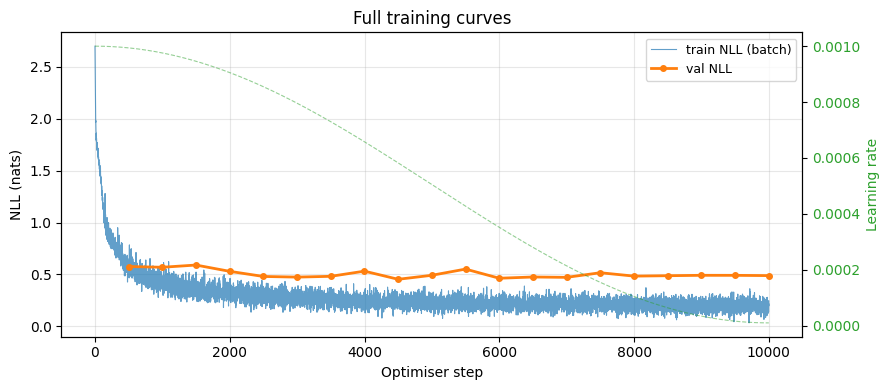

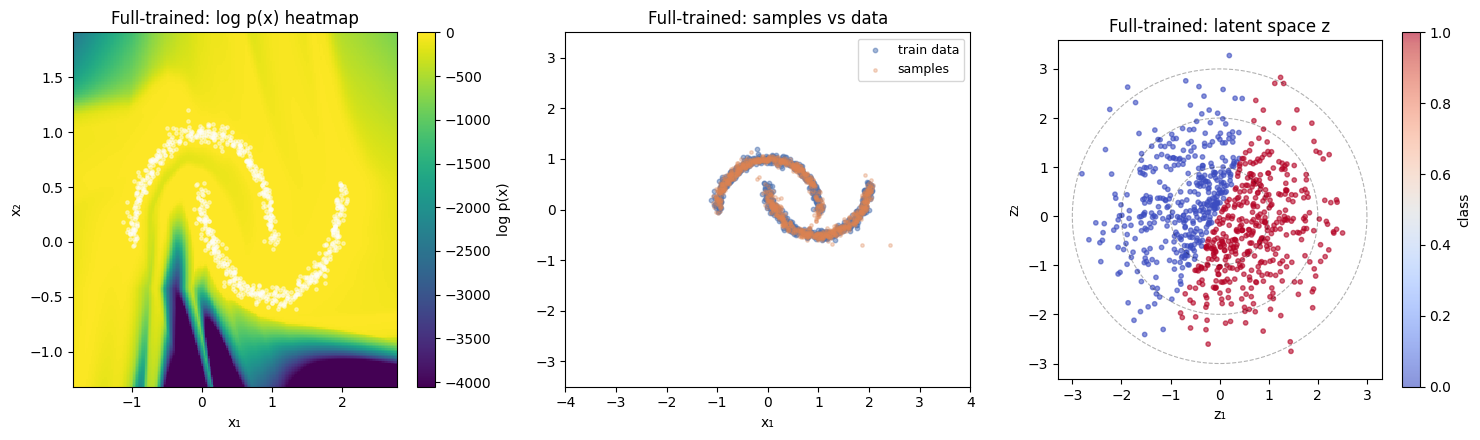


Model                   Train NLL      Val NLL     Test NLL
------------------------------------------------------------
Untrained                  2.8504       2.9160            -
Tiny-trained               0.0715            -            -
Full-trained               0.1974       0.4887       0.5633


In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Full Training ─────────────────────────────────────────────────────────────
FULL_CONFIG = {'hidden': 64, 'n_layers': 6}
flow_full = CouplingFlow2D(dim=2, **FULL_CONFIG).to(DEVICE).double()

LR_FULL = 1e-3
N_STEPS_FULL = 10_000
BATCH_FULL = 256

optimizer_full = optim.Adam(flow_full.parameters(), lr=LR_FULL)
scheduler = CosineAnnealingLR(optimizer_full, T_max=N_STEPS_FULL, eta_min=1e-5)

full_loss_curve, full_val_curve, lr_curve = [], [], []
rng_full = torch.Generator(); rng_full.manual_seed(SEED)
N_train = len(train_x)

flow_full.train()
for step in range(N_STEPS_FULL):
    idx = torch.randint(0, N_train, (BATCH_FULL,), generator=rng_full)
    xb = train_x[idx]
    optimizer_full.zero_grad()
    nll = -flow_full.log_prob(xb).mean()
    nll.backward()
    torch.nn.utils.clip_grad_norm_(flow_full.parameters(), 5.0)
    optimizer_full.step()
    scheduler.step()
    full_loss_curve.append(float(nll.item()))
    lr_curve.append(scheduler.get_last_lr()[0])
    if (step + 1) % 500 == 0:
        flow_full.eval()
        with torch.no_grad():
            val_nll = -flow_full.log_prob(val_x).mean().item()
        full_val_curve.append((step, val_nll))
        flow_full.train()
        print(f'  step {step+1:5d}/{N_STEPS_FULL}  train NLL={nll.item():.4f}  val NLL={val_nll:.4f}')

flow_full.eval()
Path('checkpoints').mkdir(parents=True, exist_ok=True)
torch.save({'state_dict': flow_full.state_dict(), 'config': FULL_CONFIG, 'seed': SEED},
           'checkpoints/flow_full.pt')
print('Checkpoint saved to checkpoints/flow_full.pt')

# ── Figure 2c: train/val curves + LR schedule ────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(full_loss_curve, color='tab:blue', linewidth=0.8, alpha=0.7, label='train NLL (batch)')
val_steps, val_nlls = zip(*full_val_curve)
ax1.plot(val_steps, val_nlls, color='tab:orange', linewidth=2, marker='o', markersize=4, label='val NLL')
ax1.set_xlabel('Optimiser step'); ax1.set_ylabel('NLL (nats)')
ax1.set_title('Full training curves'); ax1.legend(loc='upper right', fontsize=9); ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(lr_curve, color='tab:green', linewidth=0.8, alpha=0.5, linestyle='--')
ax2.set_ylabel('Learning rate', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
fig.tight_layout()
fig.savefig('figs/Figure2c.pdf', bbox_inches='tight')
plt.show()

# ── Post-training diagnostics: heatmap, samples, latent space ────────────────
with torch.no_grad():
    log_p_full = flow_full.log_prob(grid_pts).numpy().reshape(GRID_N, GRID_N)
    x_samp_full, _ = flow_full.forward(torch.randn(1000, 2, dtype=torch.float64))
    z_full, _ = flow_full.inverse(train_x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
im = ax.pcolormesh(xx_g, yy_g, log_p_full, cmap='viridis', shading='auto',
                   vmin=np.percentile(log_p_full, 5))
fig.colorbar(im, ax=ax, label='log p(x)')
ax.scatter(train_x.numpy()[:, 0], train_x.numpy()[:, 1], c='white', s=6, alpha=0.4)
ax.set_title('Full-trained: log p(x) heatmap'); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

ax = axes[1]
ax.scatter(train_x.numpy()[:, 0], train_x.numpy()[:, 1], c='#4C72B0', s=10, alpha=0.5, label='train data')
ax.scatter(x_samp_full.numpy()[:, 0], x_samp_full.numpy()[:, 1], c='#DD8452', s=6, alpha=0.3, label='samples')
ax.set_xlim(-4, 4); ax.set_ylim(-3.5, 3.5)
ax.set_title('Full-trained: samples vs data'); ax.set_xlabel('x₁'); ax.legend(fontsize=9)

ax = axes[2]
z_np = z_full.numpy()
sc = ax.scatter(z_np[:, 0], z_np[:, 1], c=train_class.numpy(), cmap='coolwarm', s=10, alpha=0.6)
theta = np.linspace(0, 2 * np.pi, 200)
for r in [1, 2, 3]:
    ax.plot(r * np.cos(theta), r * np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)
ax.set_title('Full-trained: latent space z'); ax.set_xlabel('z₁'); ax.set_ylabel('z₂'); ax.set_aspect('equal')
fig.colorbar(sc, ax=ax, label='class')

fig.tight_layout()
plt.show()

# ── Comparison table ──────────────────────────────────────────────────────────
with torch.no_grad():
    train_nll_full = -flow_full.log_prob(train_x).mean().item()
    val_nll_full = -flow_full.log_prob(val_x).mean().item()
    test_nll_full = -flow_full.log_prob(test_x).mean().item()

print(f"\n{'Model':<20} {'Train NLL':>12} {'Val NLL':>12} {'Test NLL':>12}")
print('-' * 60)
print(f"{'Untrained':<20} {train_nll_untrained:>12.4f} {val_nll_untrained:>12.4f} {'-':>12}")
print(f"{'Tiny-trained':<20} {tinyset_final_nll:>12.4f} {'-':>12} {'-':>12}")
print(f"{'Full-trained':<20} {train_nll_full:>12.4f} {val_nll_full:>12.4f} {test_nll_full:>12.4f}")


## 6) Flow Surgery (One-Parameter Family)

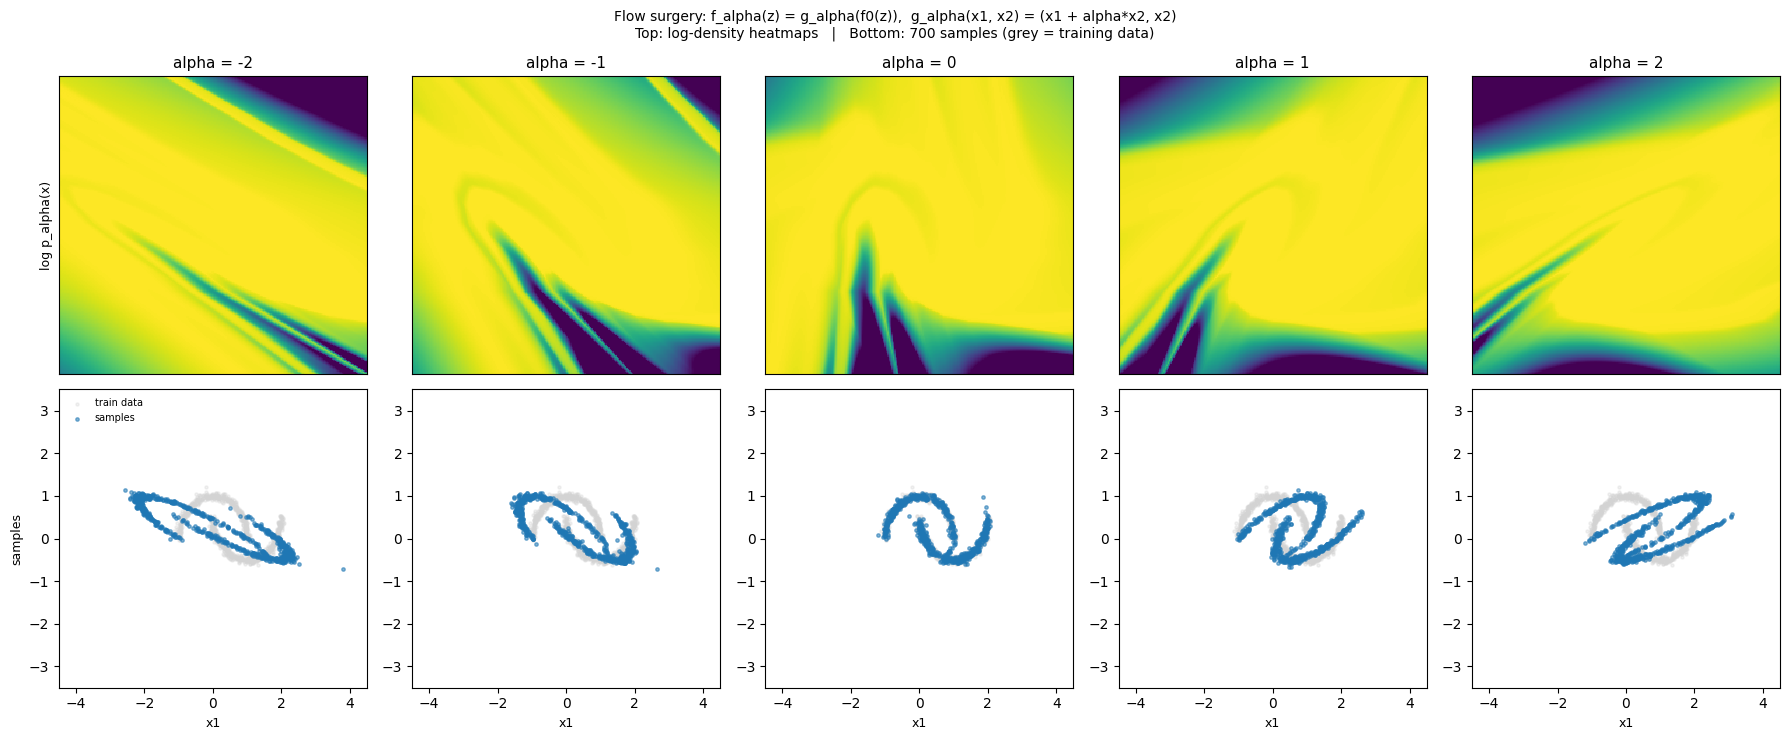

Saved figs/Figure3b.pdf


In [ ]:
# -- Flow Surgery (One-Parameter Family) ----------------------------------------
ckpt = torch.load('checkpoints/flow_full.pt', map_location=DEVICE)
flow_trained = CouplingFlow2D(dim=2, **ckpt['config']).to(DEVICE).double()
flow_trained.load_state_dict(ckpt['state_dict'])
flow_trained.eval()

# Required shear map:
#   g_alpha(x1, x2) = (x1 + alpha*x2, x2)
# Jacobian:
#   [[1, alpha],
#    [0,    1 ]]
# so det(J_g) = 1 for all alpha, hence log|det J_g| = 0.
def g_alpha(x: torch.Tensor, alpha: float):
    y = torch.stack([x[:, 0] + alpha * x[:, 1], x[:, 1]], dim=1)
    logdet = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    return y, logdet


def g_alpha_inverse(y: torch.Tensor, alpha: float):
    x = torch.stack([y[:, 0] - alpha * y[:, 1], y[:, 1]], dim=1)
    logdet = torch.zeros(y.shape[0], dtype=y.dtype, device=y.device)
    return x, logdet


# Optional alias if referenced elsewhere
g_alpha_forward = g_alpha


def f_alpha_log_prob(x: torch.Tensor, alpha: float) -> torch.Tensor:
    """
    log p_alpha(x) where f_alpha(z) = g_alpha(f0(z)).

    By change of variables:
      log p_alpha(x) = log p0(g_alpha^{-1}(x)) + log|det J_{g_alpha^{-1}}|
    Since det(J_g) = 1, the log-det term is zero.
    """
    x_pre, g_inv_logdet = g_alpha_inverse(x, alpha)
    return flow_trained.log_prob(x_pre) + g_inv_logdet


def f_alpha_sample(n: int, alpha: float) -> torch.Tensor:
    with torch.no_grad():
        z = torch.randn(n, 2, dtype=torch.float64, device=DEVICE)
        x0, _ = flow_trained.forward(z)
        x_alpha, _ = g_alpha(x0, alpha)
    return x_alpha


# -- Figure 3b: exactly five alpha values --------------------------------------
# Top row: density heatmap
# Bottom row: samples
alphas = [-2, -1, 0, 1, 2]
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

train_np = train_x.cpu().numpy()

for col, alpha in enumerate(alphas):
    # Top row: log-density heatmap
    ax_h = axes[0, col]
    with torch.no_grad():
        log_p_a = f_alpha_log_prob(grid_pts, alpha).cpu().numpy().reshape(GRID_N, GRID_N)
    im = ax_h.pcolormesh(xx_g, yy_g, log_p_a, cmap='viridis', shading='auto',
                         vmin=np.percentile(log_p_a, 5))
    ax_h.set_title(f'alpha = {alpha}', fontsize=11)
    ax_h.set_xticks([])
    ax_h.set_yticks([])
    if col == 0:
        ax_h.set_ylabel('log p_alpha(x)', fontsize=9)

    # Bottom row: samples
    ax_s = axes[1, col]
    x_s = f_alpha_sample(700, alpha).cpu().numpy()
    ax_s.scatter(train_np[:, 0], train_np[:, 1],
                 c='lightgray', s=5, alpha=0.30, label='train data')
    ax_s.scatter(x_s[:, 0], x_s[:, 1],
                 c='tab:blue', s=6, alpha=0.55, label='samples')
    ax_s.set_xlim(-4.5, 4.5)
    ax_s.set_ylim(-3.5, 3.5)
    ax_s.set_xlabel('x1', fontsize=9)
    if col == 0:
        ax_s.set_ylabel('samples', fontsize=9)
        ax_s.legend(fontsize=7, frameon=False, loc='upper left')

fig.suptitle(
    'Flow surgery: f_alpha(z) = g_alpha(f0(z)),  g_alpha(x1, x2) = (x1 + alpha*x2, x2)\n'
    'Top: log-density heatmaps   |   Bottom: 700 samples (grey = training data)',
    fontsize=10,
)
fig.tight_layout()
fig.savefig('figs/Figure3b.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved figs/Figure3b.pdf')

## 7) FLOP Counting

In [11]:
def count_flops(*, dim: int, n_layers: int, hidden: int, batch_size: int) -> int:
    """
    Analytical FLOP count for evaluating log p(x) for a batch.

    Derived from the mathematical structure of the coupling flow, not from
    implementation-specific PyTorch masking/broadcasting steps.

    Per coupling layer (inverse pass):
      Linear(D -> H)           : 2*D*H
      ReLU(H)                  : H
      Linear(H -> 2D)          : 4*D*H
      tanh on D scale values   : 10*D

      Inverse transform on m = D//2 transformed coordinates:
        x_m - t_m              : m
        -s_m                   : m
        exp(-s_m)              : 10*m
        (x_m - t_m) * exp(-s_m): m

      Log-det accumulation:
        sum over m values      : max(m - 1, 0)
        negation               : 1
        accumulate             : 1

    Pass-through coordinates involve no arithmetic (indexing only).
    Base-density evaluation costs 20 FLOPs per example, as specified.
    Combining base log-prob with total log-det costs 1 FLOP per example.

    Notes:
    - dim must be even.
    - K = n_layers is assumed to be the total number of coupling layers.
    - This function counts FLOPs for evaluating log p(x), i.e. inverse pass only.
    """
    if dim <= 0 or dim % 2 != 0:
        raise ValueError('dim must be a positive even integer.')
    if n_layers < 0:
        raise ValueError('n_layers must be non-negative.')
    if hidden <= 0:
        raise ValueError('hidden must be positive.')
    if batch_size <= 0:
        raise ValueError('batch_size must be positive.')

    m = dim // 2  # transformed dimensions per layer

    # MLP
    flops_linear1 = 2 * dim * hidden
    flops_relu = hidden
    flops_linear2 = 2 * hidden * (2 * dim)
    flops_tanh = 10 * dim

    # Inverse affine transform on transformed half
    flops_sub = m
    flops_neg_s = m
    flops_exp = 10 * m
    flops_mul = m

    # log-det accumulation
    flops_sum_ld = max(m - 1, 0)
    flops_neg_ld = 1
    flops_accum = 1

    per_layer = (
        flops_linear1
        + flops_relu
        + flops_linear2
        + flops_tanh
        + flops_sub
        + flops_neg_s
        + flops_exp
        + flops_mul
        + flops_sum_ld
        + flops_neg_ld
        + flops_accum
    )

    per_example = n_layers * per_layer + 20 + 1
    return int(batch_size * per_example)


# Coursework model example
flops_b1 = count_flops(dim=2, n_layers=6, hidden=64, batch_size=1)
print(f'FLOPs for log p(x), batch=1  : {flops_b1}')
print(f'FLOPs for log p(x), batch=800: {count_flops(dim=2, n_layers=6, hidden=64, batch_size=800)}')

# Sweep table
print(f"\n{'hidden':>8} {'n_layers':>10} {'FLOPs (B=1)':>14}")
print('-' * 36)
for h in [32, 64, 128]:
    for nl in [2, 4, 6, 8]:
        print(f'{h:>8} {nl:>10} {count_flops(dim=2, n_layers=nl, hidden=h, batch_size=1):>14}')

FLOPs for log p(x), batch=1  : 5223
FLOPs for log p(x), batch=800: 4178400

  hidden   n_layers    FLOPs (B=1)
------------------------------------
      32          2            923
      32          4           1825
      32          6           2727
      32          8           3629
      64          2           1755
      64          4           3489
      64          6           5223
      64          8           6957
     128          2           3419
     128          4           6817
     128          6          10215
     128          8          13613


## 8) Artifact Export

Write all required coursework artifacts with strict schema-compliant keys.


In [ ]:
# -- Final artifact export ------------------------------------------------------
Path('logs').mkdir(parents=True, exist_ok=True)
Path('checkpoints').mkdir(parents=True, exist_ok=True)
Path('figs').mkdir(parents=True, exist_ok=True)

# Recompute tiny-set metric cleanly under eval/no_grad
flow_tiny.eval()
with torch.no_grad():
    tinyset_final_nll = -flow_tiny.log_prob(tiny_x).mean().item()

# Save required training-curves log schema
training_curves = {
    'tiny_loss': [float(v) for v in tiny_loss_curve],
    'full_loss': [float(v) for v in full_loss_curve],
    'full_val_loss': [float(v) for _, v in full_val_curve],
}
with open('logs/training_curves.json', 'w', encoding='utf-8') as f:
    json.dump(training_curves, f, indent=2)

# Final writeup: <= 500 words
writeup = (
    "### Correctness Checks\n"
    f"Both checks were run on the untrained flow. The invertibility test applied z = f^-1(x) "
    f"followed by x_hat = f(z) to every training point and gave maximum reconstruction error "
    f"`{invertibility_max_abs_error:.3e}`, which is at floating-point precision and confirms "
    f"the implementation is numerically invertible. The log-determinant check used central "
    f"differences with epsilon = 1e-4 on the first training example and compared the numerical "
    f"log|det J_(f^-1)| to the analytic value, giving absolute error "
    f"`{logdet_finite_diff_abs_error:.3e}`. This confirms the Jacobian log-determinant formula "
    f"is implemented correctly.\n\n"

    "### Training Choices and Diagnostics\n"
    f"The final model uses {FULL_CONFIG['n_layers']} affine coupling layers with hidden size "
    f"{FULL_CONFIG['hidden']} and alternating masks [1,0] / [0,1], satisfying the coursework "
    f"limits. On the tiny subset (first 128 rows), Adam with learning rate 1e-3 for 2000 steps "
    f"reduced the NLL to `{tinyset_final_nll:.4f}`, confirming that optimisation works on a small "
    f"sanity-check problem. For full training, I used Adam, cosine annealing from 1e-3 to 1e-5, "
    f"batch size 256, 10000 optimiser steps, and gradient clipping at 5.0. Final NLLs were "
    f"train `{train_nll_full:.4f}`, validation `{val_nll_full:.4f}`, and test `{test_nll_full:.4f}`. "
    f"The validation curve improved early and then plateaued, while the lower training NLL suggests "
    f"mild overfitting on the small dataset.\n\n"

    "### Surgery Map\n"
    "The surgery map is the required shear g_alpha(x1, x2) = (x1 + alpha*x2, x2). Its Jacobian "
    "has determinant 1 for all alpha, so it is volume-preserving and contributes zero log-det. "
    "Appending this map after the trained sampler changes the geometry of generated samples by "
    "shearing them along the x1 direction without retraining the flow. Positive alpha shears to "
    "the right and negative alpha to the left.\n\n"

    "### FLOP Counting Assumptions\n"
    "FLOPs were derived analytically from the coupling-layer equations rather than from PyTorch "
    "execution. I counted the two linear layers, ReLU, tanh on the scale outputs, the inverse "
    "affine transform on the transformed half of the coordinates, log-det accumulation, the fixed "
    "20-FLOP base-density cost, and one addition to combine base log-prob with total log-det. "
    "Pass-through coordinates were treated as indexing only, so implementation-specific masking "
    "or broadcasting operations were excluded."
)

word_count = len(writeup.split())
print(f'Writeup word count: {word_count}')
if word_count > 500:
    raise RuntimeError(f'Writeup exceeds 500 words: {word_count}')

results = update_results_json(
    'results.json',
    {
        'training': {
            'tinyset_final_nll': tinyset_final_nll,
            'final_train_nll': train_nll_full,
            'final_val_nll': val_nll_full,
            'final_test_nll': test_nll_full,
        },
        'writeup': writeup,
    },
)

# Validate checkpoint schema
ckpt = torch.load('checkpoints/flow_full.pt', map_location='cpu')
expected_ckpt_keys = {'state_dict', 'config', 'seed'}
if set(ckpt.keys()) != expected_ckpt_keys:
    raise RuntimeError(f'Checkpoint keys mismatch: expected {expected_ckpt_keys}, got {set(ckpt.keys())}')

# Required artifact checklist
required = [
    'coursework.ipynb',
    'results.json',
    'figs/Figure1c.pdf',
    'figs/Figure2a.pdf',
    'figs/Figure2c.pdf',
    'figs/Figure3b.pdf',
    'checkpoints/flow_full.pt',
    'logs/training_curves.json',
]

print('-- Final artifact checklist --')
for p in required:
    status = 'OK' if Path(p).exists() else 'MISSING'
    print(f'  {status:7s} {p}')

print()
print('Saved results.json and logs/training_curves.json.')
results_preview = json.dumps(results, indent=2, sort_keys=True)
print(results_preview[:1500] + ('...' if len(results_preview) > 1500 else ''))

Writeup word count: 333
-- Final artifact checklist --
  OK      coursework.ipynb
  OK      results.json
  OK      figs/Figure1c.pdf
  OK      figs/Figure2a.pdf
  OK      figs/Figure2c.pdf
  OK      figs/Figure3b.pdf
  OK      checkpoints/flow_full.pt
  OK      logs/training_curves.json

Saved results.json and logs/training_curves.json.
{
  "correctness": {
    "invertibility_max_abs_error": 9.992007221626409e-16,
    "logdet_finite_diff_abs_error": 1.4130308034765449e-11
  },
  "training": {
    "tinyset_final_nll": 0.05316516094481268,
    "final_train_nll": 0.1974478424951403,
    "final_val_nll": 0.488738536348701,
    "final_test_nll": 0.5633496506269405
  },
  "writeup": "### Correctness Checks\nBoth checks were run on the untrained flow. The invertibility test applied z = f^-1(x) followed by x_hat = f(z) to every training point and gave maximum reconstruction error `9.992e-16`, which is at floating-point precision and confirms the implementation is numerically invertible. The lo